In [1]:
import time
start_time=time.time()


VIENTO pipeline

- Velocity Field
- Structure Function B(r) computation
- B(r) fit parameter ( 3 and 5 -parameter model) and confidence intervals determination
- Comparison between different results
- See what we have, what it is needed, if works, etc.

In [11]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import load_modelresult

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

#from turb_utils import make_extended, make_3dfield
#import strucfunc                   
import ci_results_compiler
import fit_structure_function
import bfunc
import bplot

In [30]:
name = 'fake_map_mod_finite_m2.85_r32_N512'
#r0    = 32
#sig   = 1.0
#sig2  = sig**2
#s0    = 0
#noise = 0
#pix   = 1
#pc    = 1
#box_size = 512

# Loading and Plotting velocity field

In [4]:
hdul = fits.open('fake_maps_data/' + name + '.fits')

m2D      = hdul[0].header['M2D']
ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_13484\147240807.py:8: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


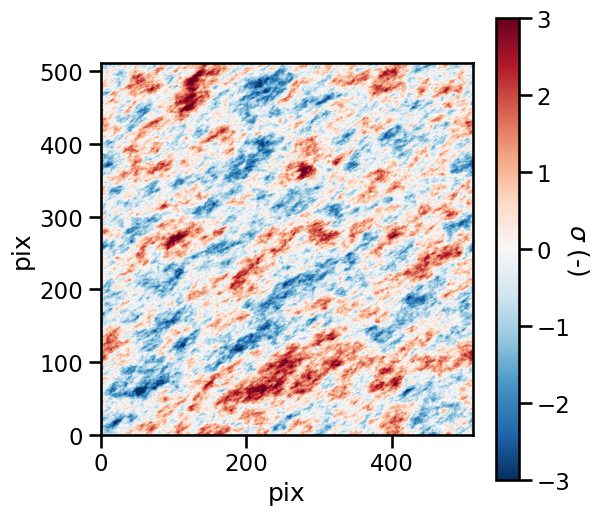

In [5]:
vv = hdul[0].data.astype(float)

fig, ax = plt.subplots(figsize=(6,6))

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vv,**imshow_kwds )
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
ax.set_xlabel("pix")
ax.set_ylabel("pix")

None

# Plotting structure function

In [31]:
Br_init = json.load(open( "results/" + name + ".json"))
Br      = Br_init['strucfun_numba_parallel']
B       = 10**np.array(Br['log10 r'])
r       = Br['Unweighted B(r)']

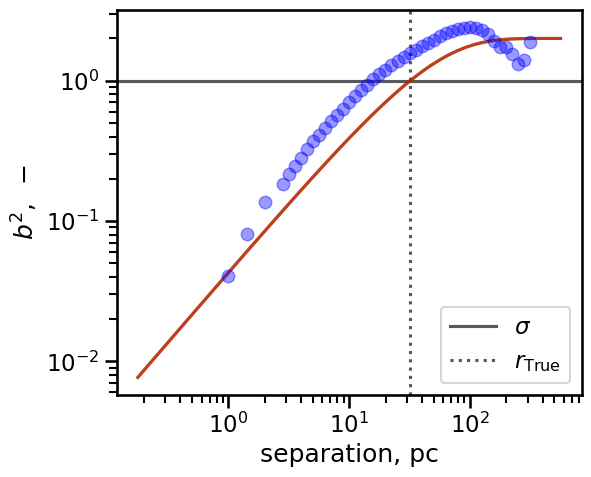

In [10]:
m   = 1.0
sig2norm = 1.0


fig, ax = plt.subplots(figsize=(6, 5))
rgrid = np.logspace(-0.75, 2.75)
ax.errorbar(10**np.array(Br['log10 r']), Br['Unweighted B(r)'], fmt='o', alpha=0.4,color="blue")
#ax.errorbar(s, b2w, yerr=e_b2w, xerr=e_s, fmt='x', alpha=0.4,color="green")

ax.axhline(sig2norm, ls='-', label = r'$\sigma$', color="black", alpha = 0.65)
ax.axvline(ra, ls=':', label = r'$r_\text{True}$', color="black", alpha = 0.65)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, ra, sig2norm, m), color="green", alpha = 0.65)
ax.plot(rgrid, bfunc.bfunc03s(rgrid, ra, sig2norm, m, s0, noise), color="red", alpha = 0.65)

ax.set(xscale='log', yscale='log', 
       xlabel='separation, pc',
#       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
       ylabel=r'$b^2,\ -$'
      )

ax.legend()


None

# Loading Fit and confidence intervals

In [17]:
result = load_modelresult("result.sav")
result_emcee = load_modelresult("result_emcee.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

In [25]:
params_Br = ci_results_compiler.ci_results_compiler(fit_Br)
params_Br

{'sig2': [1.070854321991615, 0.07714226206088481, 0.04030228082911491],
 'r0': [10.319554518179945, 0.9834442976400553, 1.1879079079599446],
 'm': [0.8663257264669567, 0.08229130993304323, 0.13555172489695666],
 's0': [0.40607546914228765, 0.5992365916702123, 0.0927496664372876],
 'noise': [2.0951032314598558e-12,
  0.05122359225040489,
  -0.0005821412129048969]}

# Plotting Fit results and confidence intervals

In [33]:
# name = 'x'
# data = 'c'

# bplot.corner_plot(
#    result_emcee, result, name, data, data_ranges=[0.95, 0.99, 0.995, 0.997, 0.999]
# )

In [34]:
#bplot.strucfunc_plot(
#    result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
#)

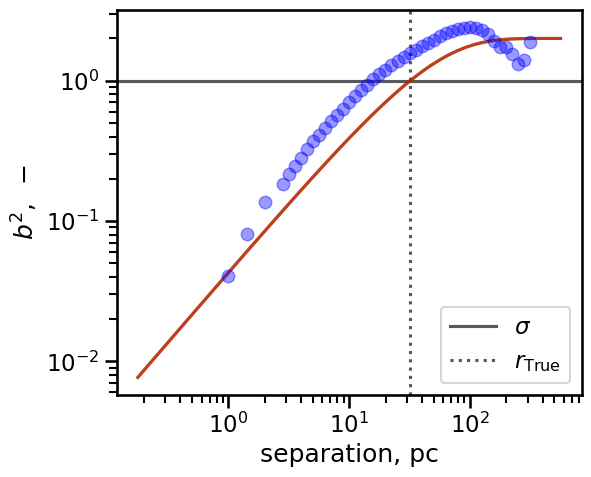

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
rgrid = np.logspace(-0.75, 2.75)
ax.errorbar(10**np.array(Br['log10 r']), Br['Unweighted B(r)'], fmt='o', alpha=0.4,color="blue")
#ax.errorbar(s, b2w, yerr=e_b2w, xerr=e_s, fmt='x', alpha=0.4,color="green")

ax.axhline(sig2norm, ls='-', label = r'$\sigma$', color="black", alpha = 0.65)
ax.axvline(ra, ls=':', label = r'$r_\text{True}$', color="black", alpha = 0.65)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, ra, sig2norm, m), color="green", alpha = 0.65)
ax.plot(rgrid, bfunc.bfunc03s(rgrid, ra, sig2norm, m, s0, noise), color="red", alpha = 0.65)

ax.set(xscale='log', yscale='log', 
       xlabel='separation, pc',
#       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
       ylabel=r'$b^2,\ -$'
      )

ax.legend()


None

In [9]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 7.5199034214019775 seconds ---
